# 01 — Exploratory Data Analysis with PySpark
### ST5011CEM · *When Does the Road Fill?* · DfT GB Road Traffic Counts

Profiling and EDA on **5.27M real hourly traffic counts**, using PySpark functions throughout.
Nothing here is simulated.

This notebook is a thin wrapper over `src/` — it imports the same modules the pipeline runs,
so the numbers shown are the numbers the pipeline uses. It does not re-implement anything.

**Prerequisite:** `python run_pipeline.py --from process --skip-ml` (writes `counts.parquet`).

## 1. Spark session

One configuration, defined in `src/spark_session.py` — not redefined here.

In [1]:
import sys; sys.path.insert(0, "..")
from pyspark.sql import functions as F, Window
from src.spark_session import get_spark
from src.config import resolve, load_config

spark = get_spark("notebook_eda")
cfg = load_config()

print("Spark version:      ", spark.version)
print("Master:             ", spark.sparkContext.master)
print("Shuffle partitions: ", spark.conf.get("spark.sql.shuffle.partitions"))
print("Spark UI:           ", spark.sparkContext.uiWebUrl, " <-- screenshot this while a job runs")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/17 12:25:17 WARN Utils: Your hostname, Bishowdips-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.68 instead (on interface en0)
26/07/17 12:25:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/17 12:25:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version:       4.1.1
Master:              local[4]
Shuffle partitions:  8
Spark UI:            http://192.168.1.68:4040  <-- screenshot this while a job runs


## 2. Load — Spark DataFrames, partitioned Parquet

The clean table is written `partitionBy("year")`. That is what makes the time-aware split
partition *pruning* rather than a full scan.

In [2]:
counts = spark.read.parquet(str(resolve("processed") / "counts.parquet"))

print(f"rows:       {counts.count():,}")
print(f"partitions: {counts.rdd.getNumPartitions()}")
counts.printSchema()

rows:       5,269,609
partitions: 4
root
 |-- count_point_id: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- region_id: string (nullable = true)
 |-- region_name: string (nullable = true)
 |-- local_authority_id: string (nullable = true)
 |-- local_authority_name: string (nullable = true)
 |-- road_name: string (nullable = true)
 |-- road_category: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- easting: double (nullable = true)
 |-- northing: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- link_length_km: double (nullable = true)
 |-- pedal_cycles: integer (nullable = true)
 |-- two_wheeled_motor_vehicles: integer (nullable = true)
 |-- cars_and_taxis: integer (nullable = true)
 |-- buses_and_coaches: integer (nullable = true)
 |-- LGVs: integer (nullable = true)
 |-- all_HGVs: integer (nullable = true)
 |-- all_motor_vehicles: in

## 3. Big Data Scale — evidencing the 100,000-record requirement

Met **53x over by one real table**. No synthetic augmentation anywhere in this project.

In [3]:
processed = resolve("processed")
for name in ["counts", "aadf", "hourly_profile", "dim_count_point"]:
    path = processed / f"{name}.parquet"
    if path.exists():
        print(f"{name:<18} {spark.read.parquet(str(path)).count():>10,}")
print(f"\n{'requirement':<18} {100_000:>10,}")

counts              5,269,609
aadf                  600,551


hourly_profile        520,812
dim_count_point        43,401

requirement           100,000


## 4. THE LEAKAGE PROOF

The single most important cell in this project. The mode columns are not correlates of the
target — they are its **exact components**. Any model given one of them re-adds the parts
and reports R² ≈ 1.0.

In [4]:
mode_sum = (F.coalesce(F.col("two_wheeled_motor_vehicles"), F.lit(0))
            + F.coalesce(F.col("cars_and_taxis"), F.lit(0))
            + F.coalesce(F.col("buses_and_coaches"), F.lit(0))
            + F.coalesce(F.col("LGVs"), F.lit(0))
            + F.coalesce(F.col("all_HGVs"), F.lit(0)))

check = counts.withColumn("mode_sum", mode_sum) \
              .withColumn("diff", F.col("mode_sum") - F.col("all_motor_vehicles"))

total = check.count()
exact = check.filter(F.col("diff") == 0).count()
print("two_wheeled + cars + buses + LGVs + all_HGVs == all_motor_vehicles")
print(f"  holds on {exact:,} / {total:,} rows = {exact/total:.4%}")
print("\n=> every mode column is a COMPONENT of the target. Using one as a feature is leakage.\n")

for c in ["cars_and_taxis", "LGVs", "all_HGVs", "buses_and_coaches", "pedal_cycles"]:
    print(f"  corr({c:<26}, target) = {counts.stat.corr(c, 'all_motor_vehicles'):+.4f}")

two_wheeled + cars + buses + LGVs + all_HGVs == all_motor_vehicles
  holds on 5,269,608 / 5,269,609 rows = 100.0000%

=> every mode column is a COMPONENT of the target. Using one as a feature is leakage.



  corr(cars_and_taxis            , target) = +0.9908


  corr(LGVs                      , target) = +0.9255
  corr(all_HGVs                  , target) = +0.8023


  corr(buses_and_coaches         , target) = +0.3675
  corr(pedal_cycles              , target) = +0.0289


The guard is enforced in code, not just documented. This cell proves it fires.

In [5]:
from src.ml.train_models import assert_no_leakage
from src.ml import features

assert_no_leakage()
print("PASS: the real feature list is clean.\n")

original = features.ALL_FEATURES
try:
    import src.ml.train_models as tm
    tm.ALL_FEATURES = original + ["cars_and_taxis"]      # deliberately break it
    tm.assert_no_leakage()
    print("BUG: the guard did not fire!")
except RuntimeError as e:
    print(f"PASS: guard fired as designed ->\n  {e}")
finally:
    tm.ALL_FEATURES = original

PASS: the real feature list is clean.

PASS: guard fired as designed ->
  LEAKAGE: target components used as features: cars_and_taxis (exact component of the target (r=0.991))


## 5. Data quality profiling

Nulls, cardinality, and the finding that changed the feature set.

In [6]:
counts.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in ["all_motor_vehicles", "link_length_km", "latitude", "count_date", "road_category"]
]).show(truncate=False)

counts.select(
    F.approx_count_distinct("count_point_id").alias("count_points"),
    F.approx_count_distinct("road_name").alias("road_names"),
    F.countDistinct("year").alias("years"),
    F.countDistinct("hour").alias("hours"),
    F.countDistinct("region_name").alias("regions"),
    F.countDistinct("direction_of_travel").alias("directions"),
).show()

+------------------+--------------+--------+----------+-------------+
|all_motor_vehicles|link_length_km|latitude|count_date|road_category|
+------------------+--------------+--------+----------+-------------+
|0                 |2888195       |0       |0         |0            |
+------------------+--------------+--------+----------+-------------+



26/07/17 12:25:25 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+----------+-----+-----+-------+----------+
|count_points|road_names|years|hours|regions|directions|
+------------+----------+-----+-----+-------+----------+
|       43270|      3612|   26|   12|     11|         6|
+------------+----------+-----+-----+-------+----------+



### `link_length_km` is not missing data — it is road class

54.8% null looks like a gappy column until you split it by road class.

In [7]:
counts.groupBy("road_category").agg(
    F.count("*").alias("rows"),
    F.round(100 * F.mean(F.col("link_length_km").isNull().cast("double")), 1).alias("pct_null"),
).orderBy(F.desc("rows")).show()

print("A perfect 100% / 0% break. DfT defines junction-to-junction links only on the major")
print("network (PA/TA/TM/PM), never on minor roads (MCU/MB). The column is road class")
print("encoded as missingness -> excluded from the feature set.")

+-------------+-------+--------+
|road_category|   rows|pct_null|
+-------------+-------+--------+
|          MCU|2297436|   100.0|
|           PA|1753158|     0.0|
|           MB| 590759|   100.0|
|           TA| 391520|     0.0|
|           TM| 230928|     0.0|
|           PM|   5808|     0.0|
+-------------+-------+--------+

A perfect 100% / 0% break. DfT defines junction-to-junction links only on the major
network (PA/TA/TM/PM), never on minor roads (MCU/MB). The column is road class
encoded as missingness -> excluded from the feature set.


## 6. Distribution statistics via Spark functions

The brief names skewness and kurtosis specifically. Both computed with Spark, not pandas.

In [8]:
counts.select(
    F.round(F.mean("all_motor_vehicles"), 2).alias("mean"),
    F.round(F.expr("percentile_approx(all_motor_vehicles, 0.5)"), 2).alias("median"),
    F.round(F.stddev("all_motor_vehicles"), 2).alias("std"),
    F.round(F.skewness("all_motor_vehicles"), 3).alias("skewness"),
    F.round(F.kurtosis("all_motor_vehicles"), 3).alias("kurtosis"),
    F.min("all_motor_vehicles").alias("min"),
    F.max("all_motor_vehicles").alias("max"),
).show(truncate=False)

+------+------+------+--------+--------+---+-----+
|mean  |median|std   |skewness|kurtosis|min|max  |
+------+------+------+--------+--------+---+-----+
|551.63|237   |839.53|2.945   |10.84   |0  |10905|
+------+------+------+--------+--------+---+-----+



**Reading the shape.** The mean is ~2.3x the median: a severe right tail. A handful of
motorway links carry thousands of vehicles per hour while most roads carry tens. This is why
the median describes a typical hour, why RMSE on raw flow is dominated by the busiest links,
and — ultimately — why R² on this target is mostly *between-link* variance.

## 7. Outliers — IQR method

In [9]:
q1, q3 = counts.approxQuantile("all_motor_vehicles", [0.25, 0.75], 0.01)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = counts.filter((F.col("all_motor_vehicles") < low)
                         | (F.col("all_motor_vehicles") > high)).count()

print(f"Q1 = {q1:,.0f}   Q3 = {q3:,.0f}   IQR = {iqr:,.0f}")
print(f"Fences: [{low:,.0f}, {high:,.0f}]")
print(f"Outliers: {outliers:,} ({outliers/counts.count():.1%})")
print("\nThese are real motorways, not errors - the distribution is genuinely heavy-tailed.")

Q1 = 51   Q3 = 662   IQR = 611
Fences: [-866, 1,578]
Outliers: 473,408 (9.0%)

These are real motorways, not errors - the distribution is genuinely heavy-tailed.


## 8. Spark SQL — the shape of the day

The signal this whole project exists to forecast.

In [10]:
counts.createOrReplaceTempView("counts")

spark.sql("""
    SELECT hour,
           COUNT(*)                        AS observations,
           ROUND(AVG(all_motor_vehicles),1) AS mean_flow,
           ROUND(AVG(cars_and_taxis),1)     AS mean_cars,
           ROUND(AVG(pedal_cycles),1)       AS mean_cycles
    FROM counts
    GROUP BY hour
    ORDER BY hour
""").show(24, truncate=False)

+----+------------+---------+---------+-----------+
|hour|observations|mean_flow|mean_cars|mean_cycles|
+----+------------+---------+---------+-----------+
|7   |439130      |586.8    |434.6    |3.7        |
|8   |439134      |644.2    |504.8    |4.7        |
|9   |439133      |513.2    |380.2    |2.6        |
|10  |439135      |464.4    |336.7    |1.7        |
|11  |439135      |471.1    |342.9    |1.6        |
|12  |439135      |486.9    |361.1    |1.8        |
|13  |439134      |500.4    |371.9    |1.9        |
|14  |439136      |522.6    |389.3    |2.0        |
|15  |439135      |576.6    |439.3    |2.6        |
|16  |439135      |649.5    |513.4    |3.4        |
|17  |439135      |669.2    |563.4    |4.6        |
|18  |439132      |534.8    |459.9    |4.1        |
+----+------------+---------+---------+-----------+



Note each hour holds exactly 1/12 of the file: DfT counts run a **12-hour day,
07:00–18:59**. There is no night-time data.

## 9. Lazy evaluation and the DAG

Transformations build a plan; only an action runs it. `explain()` shows the physical plan,
including the partition pruning the `partitionBy("year")` write buys us.

In [11]:
plan = (counts.filter(F.col("year") >= 2023)
              .groupBy("hour")
              .agg(F.mean("all_motor_vehicles").alias("mean_flow")))

print("No job has run yet - the above is only a plan.\n")
plan.explain(mode="simple")

No job has run yet - the above is only a plan.

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[hour#2], functions=[avg(all_motor_vehicles#21)])
   +- Exchange hashpartitioning(hour#2, 8), ENSURE_REQUIREMENTS, [plan_id=1015]
      +- HashAggregate(keys=[hour#2], functions=[partial_avg(all_motor_vehicles#21)])
         +- Project [hour#2, all_motor_vehicles#21]
            +- FileScan parquet [hour#2,all_motor_vehicles#21,year#28] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/Users/bishowdip/Desktop/PradeeptaAsignment/Busservice/bods-relia..., PartitionFilters: [isnotnull(year#28), (year#28 >= 2023)], PushedFilters: [], ReadSchema: struct<hour:int,all_motor_vehicles:int>




In [12]:
import time
t0 = time.perf_counter()
plan.count()                      # the action that triggers the DAG
print(f"\nAction triggered execution in {time.perf_counter()-t0:.2f}s")


Action triggered execution in 0.20s


## 10. The peak index — why normalisation is the whole argument

Raw flow cannot compare a motorway with a country lane; the level gap swamps the time-of-day
shape. Dividing each link's hourly flow by its own mean strips the level out and leaves the
shape — which is what "peak hour" actually means.

In [13]:
link_window = Window.partitionBy("count_point_id")

profile = (counts.groupBy("count_point_id", "hour")
                 .agg(F.mean("all_motor_vehicles").alias("mean_flow"))
                 .withColumn("link_mean", F.mean("mean_flow").over(link_window))
                 # Guard the divide. 5 count points out of 43,401 (0.012%) recorded ZERO
                 # vehicles in every hour they were ever counted - genuinely dead roads.
                 # Their link_mean is 0, and under Spark's ANSI mode a plain division
                 # RAISES DIVIDE_BY_ZERO and kills the job rather than yielding null.
                 # Same guard as src/process/build_profiles.py.
                 .withColumn("peak_index",
                             F.when(F.col("link_mean") > 0,
                                    F.col("mean_flow") / F.col("link_mean"))))

dead = profile.filter(F.col("peak_index").isNull()).select("count_point_id").distinct().count()
print(f"links with zero flow in every hour (peak_index undefined): {dead}\n")

profile.groupBy("hour").agg(
    F.round(F.mean("peak_index"), 3).alias("mean_peak_index")
).orderBy("hour").show(24, truncate=False)

links with zero flow in every hour (peak_index undefined): 5



+----+---------------+
|hour|mean_peak_index|
+----+---------------+
|7   |0.896          |
|8   |1.24           |
|9   |0.923          |
|10  |0.838          |
|11  |0.866          |
|12  |0.895          |
|13  |0.903          |
|14  |0.947          |
|15  |1.121          |
|16  |1.189          |
|17  |1.237          |
|18  |0.945          |
+----+---------------+



**The finding.** Per link the **AM peak (08:00) marginally exceeds the PM peak (17:00)** —
the reverse of the raw-flow ordering, where PM wins. The raw result was a composition effect
of *which* links get counted, not a property of the day. Only normalisation reveals it.

## 11. The headline chart

Binned in Spark; only the bin counts are collected to pandas.

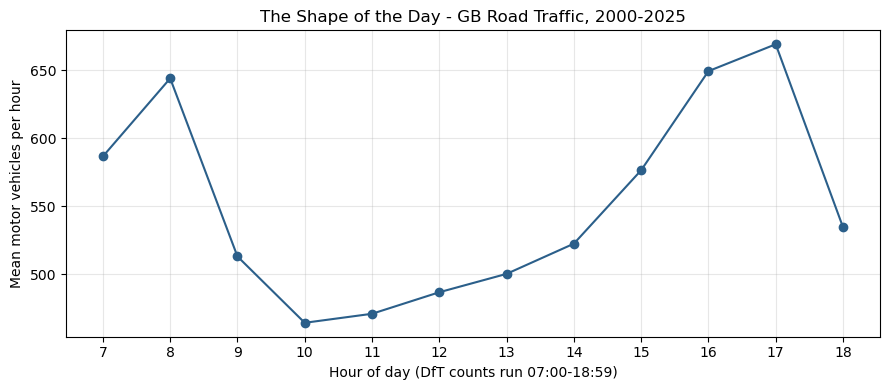

In [14]:
import matplotlib.pyplot as plt

data = (counts.groupBy("hour")
              .agg(F.mean("all_motor_vehicles").alias("mean_flow"))
              .orderBy("hour").toPandas())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(data["hour"], data["mean_flow"], marker="o", color="#2b5f8a")
ax.set_xlabel("Hour of day (DfT counts run 07:00-18:59)")
ax.set_ylabel("Mean motor vehicles per hour")
ax.set_title("The Shape of the Day - GB Road Traffic, 2000-2025")
ax.set_xticks(data["hour"]); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Correlation with the target

Worth seeing *before* any model is fitted: no legitimate feature carries the target. The
weak-signal result the models produce is visible here already.

In [15]:
for c in ["hour", "is_weekend", "month", "is_major_road", "latitude", "longitude"]:
    r = counts.stat.corr(c, "all_motor_vehicles")
    print(f"  corr({c:<15}, all_motor_vehicles) = {r:+.4f}")

print("\nNothing above ~0.2. Compare cars_and_taxis at +0.991 in section 4 - that is the")
print("difference between a feature and the answer.")

  corr(hour           , all_motor_vehicles) = +0.0192
  corr(is_weekend     , all_motor_vehicles) = +0.0006


  corr(month          , all_motor_vehicles) = -0.0348
  corr(is_major_road  , all_motor_vehicles) = +0.5575


  corr(latitude       , all_motor_vehicles) = -0.0503
  corr(longitude      , all_motor_vehicles) = +0.0610

Nothing above ~0.2. Compare cars_and_taxis at +0.991 in section 4 - that is the
difference between a feature and the answer.


In [16]:
spark.stop()